In [4]:
import pandas as pd
import numpy as np

s1 = pd.read_parquet('/Users/hojin/Documents/Domain_Adaptation_for_EMG_IMU_Sensor/data/samsung1.parquet')
s2 = pd.read_parquet('/Users/hojin/Documents/Domain_Adaptation_for_EMG_IMU_Sensor/data/samsung2_original.parquet')

In [5]:
# absolute_time이 20250610_141946 시각을 포함하는 데이터 세션(filename)을 찾는다

target_session = '20250611_140514'
target_dt = pd.to_datetime(target_session, format='%Y%m%d_%H%M%S')

# absolute_time을 datetime 형식으로 변환
s1['absolute_time'] = pd.to_datetime(s1['absolute_time'])

# 각 filename 세션별 시작/끝 시간 확인
session_ranges = (
    s1.groupby('filename')
      .agg(
          subject=('subject', 'first'),
          exercise=('exercise', 'first'),
          start_time=('absolute_time', 'min'),
          end_time=('absolute_time', 'max'),
          n_rows=('absolute_time', 'size')
      )
      .reset_index()
)

# target_dt와 가장 가까운 세션 찾기

session_ranges['time_diff_sec'] = session_ranges.apply(
    lambda row: min(
        abs((row['start_time'] - target_dt).total_seconds()),
        abs((row['end_time'] - target_dt).total_seconds())
    ),
    axis=1
)

nearest_sessions = session_ranges.sort_values('time_diff_sec').head(10)

nearest_sessions

,filename,subject,exercise,start_time,end_time,n_rows,time_diff_sec
443,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,2025-06-11 14:05:11.011253,2025-06-11 14:05:30.990733,38480,2.988747
445,sub8_deadllift_plot_and_store_rep_2.41.csv,sub8,deadlift,2025-06-11 14:06:10.642066,2025-06-11 14:06:30.621546,38480,56.642066
446,sub8_deadllift_plot_and_store_rep_3.42.csv,sub8,deadlift,2025-06-11 14:07:35.605635,2025-06-11 14:07:53.087615,33670,141.605635
447,sub8_deadllift_plot_and_store_rep_4.43.csv,sub8,deadlift,2025-06-11 14:08:56.350472,2025-06-11 14:09:05.340952,17316,222.350472
444,sub8_deadllift_plot_and_store_rep_1.44.csv,sub8,deadlift,2025-06-11 14:10:13.346069,2025-06-11 14:10:31.827049,35594,299.346069
456,sub8_ohp_plot_and_store_rep_1.45.csv,sub8,ohp,2025-06-11 14:12:19.113405,2025-06-11 14:12:32.599385,25974,425.113405
457,sub8_ohp_plot_and_store_rep_2.46.csv,sub8,ohp,2025-06-11 14:13:27.994546,2025-06-11 14:13:46.975026,36556,493.994546
458,sub8_ohp_plot_and_store_rep_3.47.csv,sub8,ohp,2025-06-11 14:14:24.675541,2025-06-11 14:14:44.155521,37518,550.675541
459,sub8_ohp_plot_and_store_rep_4.48.csv,sub8,ohp,2025-06-11 14:16:01.340056,2025-06-11 14:16:19.821036,35594,647.340056
460,sub8_ohp_plot_and_store_rep_5.49.csv,sub8,ohp,2025-06-11 14:16:57.671643,2025-06-11 14:17:09.159623,22126,703.671643


In [6]:
# Samsung 1 랫풀다운 16:24:25
s1[s1['filename'] == 'sub2_latpulldown_plot_and_store_rep_2.143.csv']

,timestamp,absolute_time,filename,subject,exercise,biceps,triceps,biceps_X,biceps_Y,biceps_Z,triceps_X,triceps_Y,triceps_Z
3922074,0.000000,2025-06-16 16:24:24.405754,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,0.000000e+00,0.000010,-0.669653,0.313900,-0.627800,-0.617336,-0.146487,-0.418533
3922075,0.000519,2025-06-16 16:24:24.406273,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,-1.007095e-06,0.000009,-0.669653,0.313095,-0.626995,-0.616532,-0.145682,-0.418533
3922076,0.001038,2025-06-16 16:24:24.406792,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,-1.510643e-06,0.000009,-0.669653,0.312290,-0.626190,-0.615727,-0.144877,-0.418533
3922077,0.001558,2025-06-16 16:24:24.407311,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,-8.392462e-07,0.000009,-0.669653,0.311485,-0.625385,-0.614922,-0.144072,-0.418533
3922078,0.002077,2025-06-16 16:24:24.407830,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,1.510643e-06,0.000008,-0.669653,0.310680,-0.624580,-0.614117,-0.143267,-0.418533
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950929,14.982404,2025-06-16 16:24:39.388157,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3950930,14.982924,2025-06-16 16:24:39.388677,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3950931,14.983442,2025-06-16 16:24:39.389196,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3950932,14.983961,2025-06-16 16:24:39.389715,sub2_latpulldown_plot_and_store_rep_2.143.csv,sub2,latpulldown,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
# Samsung 1 데드리프트 12:21:11
s1[s1['filename'] == 'sub8_deadllift_plot_and_store_rep_1.40.csv']

,timestamp,absolute_time,filename,subject,exercise,biceps,triceps,biceps_X,biceps_Y,biceps_Z,triceps_X,triceps_Y,triceps_Z
1203462,0.000000,2025-06-11 14:05:11.011253,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,-6.042573e-06,-0.000018,0.523166,0.261583,0.0,0.481313,0.512703,-0.376680
1203463,0.000519,2025-06-11 14:05:11.011772,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,-4.196231e-06,-0.000011,0.523971,0.262388,0.0,0.482118,0.510289,-0.377485
1203464,0.001038,2025-06-11 14:05:11.012291,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,-2.182040e-06,-0.000004,0.524776,0.263193,0.0,0.482923,0.507874,-0.378290
1203465,0.001558,2025-06-11 14:05:11.012810,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,-8.392462e-07,0.000004,0.525581,0.263998,0.0,0.483728,0.505459,-0.379094
1203466,0.002077,2025-06-11 14:05:11.013329,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,-5.035477e-07,0.000010,0.526386,0.264803,0.0,0.484533,0.503045,-0.379899
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241937,19.977404,2025-06-11 14:05:30.988656,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1241938,19.977922,2025-06-11 14:05:30.989176,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1241939,19.978443,2025-06-11 14:05:30.989695,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1241940,19.978962,2025-06-11 14:05:30.990214,sub8_deadllift_plot_and_store_rep_1.40.csv,sub8,deadlift,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [8]:
# Samsung 2 랫풀다운 10:42:41
s2[s2['csv_filename_l'] == 'Data_NINA11_2025.09.16_10.42.27_sub7_latpulldown_1_59_6.csv']

,TimeStamp,Index_Time,Save_Time,beep,csv_filename_l,subject_id,exercise,biceps,triceps,triceps_Y,triceps_X,triceps_Z
7903282,2025-09-16 10:42:27.309964000,0.0000,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1825.0,1846.0,415.89801,872.421997,-247.416000
7903283,2025-09-16 10:42:27.310464000,0.0005,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1848.0,1845.0,415.89801,872.421997,-247.416000
7903284,2025-09-16 10:42:27.310964000,0.0010,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1851.0,1852.0,415.89801,872.421997,-247.416000
7903285,2025-09-16 10:42:27.311464000,0.0015,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1866.0,1852.0,415.89801,872.421997,-247.416000
7903286,2025-09-16 10:42:27.311964000,0.0020,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1867.0,1860.0,415.89801,872.421997,-247.416000
...,...,...,...,...,...,...,...,...,...,...,...,...
7981787,2025-09-16 10:43:06.562464000,39.2525,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1852.0,1847.0,1002.35199,-0.976000,319.152008
7981788,2025-09-16 10:43:06.562964000,39.2530,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1852.0,1847.0,1002.35199,-0.976000,319.152008
7981789,2025-09-16 10:43:06.563464000,39.2535,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1852.0,1847.0,1002.35199,-0.976000,319.152008
7981790,2025-09-16 10:43:06.563964000,39.2540,10.42.27.309964,0,Data_NINA11_2025.09.16_10.42.27_sub7_latpulldo...,7,latpulldown,1852.0,1847.0,1002.35199,-0.976000,319.152008


In [9]:
# samsung 2 데드리프트 09:06:47
s2[s2['csv_filename_l'] == 'Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_1_40_6.csv']

,TimeStamp,Index_Time,Save_Time,beep,csv_filename_l,subject_id,exercise,biceps,triceps,triceps_Y,triceps_X,triceps_Z
3609718,2025-09-12 09:06:40.032669000,0.0000,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1846.0,1849.0,982.832031,257.420013,-88.694000
3609719,2025-09-12 09:06:40.033169000,0.0005,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1860.0,1853.0,982.832031,257.420013,-88.694000
3609720,2025-09-12 09:06:40.033669000,0.0010,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1857.0,1848.0,982.832031,257.420013,-88.694000
3609721,2025-09-12 09:06:40.034169000,0.0015,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1854.0,1843.0,982.832031,257.420013,-88.694000
3609722,2025-09-12 09:06:40.034669000,0.0020,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1851.0,1845.0,982.832031,257.420013,-88.694000
...,...,...,...,...,...,...,...,...,...,...,...,...
3690923,2025-09-12 09:07:20.635169000,40.6025,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1846.0,1846.0,768.721985,181.779999,133.223999
3690924,2025-09-12 09:07:20.635669000,40.6030,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1836.0,1847.0,768.721985,181.779999,133.223999
3690925,2025-09-12 09:07:20.636169000,40.6035,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1837.0,1851.0,768.721985,181.779999,133.223999
3690926,2025-09-12 09:07:20.636669000,40.6040,09.06.40.032669,0,Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_...,7,deadlift,1840.0,1854.0,768.721985,181.779999,133.223999


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import koreanize_matplotlib

def plot_triceps_xyz_around_time(
    df,
    filename,
    center_time,
    before=0.5,
    after=0.5,
    session_col='filename',
    abs_time_col='absolute_time',
    rel_time_col='timestamp',
    channels=('triceps_X', 'triceps_Y', 'triceps_Z'),
    title=None
):
    """
    특정 filename 세션에서 center_time을 기준으로 앞/뒤 구간의 triceps_X/Y/Z를 시각화한다.

    Parameters
    ----------
    df : pd.DataFrame
        Samsung1 데이터프레임
    filename : str
        확인할 세션 filename
    center_time : str
        기준 시각.
        예: '2025-06-16 16:24:25' 또는 '16:24:25'
        'HH:MM:SS'만 넣으면 해당 세션의 날짜를 자동으로 붙인다.
    before : float
        기준 시각 앞 몇 초를 볼지
    after : float
        기준 시각 뒤 몇 초를 볼지
    """

    # 1. 해당 세션 추출
    sdf = df[df[session_col] == filename].copy()

    if len(sdf) == 0:
        raise ValueError(f"해당 filename을 찾을 수 없습니다: {filename}")

    # 2. absolute_time datetime 변환
    sdf[abs_time_col] = pd.to_datetime(sdf[abs_time_col])
    sdf = sdf.sort_values(abs_time_col)

    # 3. center_time 처리
    # '16:24:25'처럼 시간만 넣은 경우, 세션 날짜를 자동으로 붙임
    if len(center_time.strip()) <= 12:
        session_date = sdf[abs_time_col].iloc[0].date()
        center_dt = pd.to_datetime(f"{session_date} {center_time}")
    else:
        center_dt = pd.to_datetime(center_time)

    # 4. 기준 시각 기준 앞/뒤 window 설정
    start_dt = center_dt - pd.Timedelta(seconds=before)
    end_dt   = center_dt + pd.Timedelta(seconds=after)

    wdf = sdf[
        (sdf[abs_time_col] >= start_dt) &
        (sdf[abs_time_col] <= end_dt)
    ].copy()

    if len(wdf) == 0:
        raise ValueError(
            f"선택 구간에 데이터가 없습니다.\n"
            f"center={center_dt}, range={start_dt} ~ {end_dt}"
        )

    # 5. 기준 시각을 0초로 하는 상대시간 생성
    wdf['time_from_center'] = (
        wdf[abs_time_col] - center_dt
    ).dt.total_seconds()

    # 6. 시각화
    plt.figure(figsize=(12, 4))

    for ch in channels:
        plt.plot(
            wdf['time_from_center'],
            wdf[ch],
            lw=1.2,
            label=ch
        )

    # 기준 시각 표시
    plt.axvline(0, color='black', linestyle='--', lw=1.2, label='기준 시각')

    # 보기 좋은 x축 범위
    plt.xlim(-before, after)

    if title is None:
        title = (
            f"{filename}\n"
            f"center={center_dt}  |  window={before}s before ~ {after}s after"
        )

    plt.title(title)
    plt.xlabel("기준 시각으로부터의 시간 [s]")
    plt.ylabel("triceps IMU acceleration")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("[선택 구간 정보]")
    print("filename:", filename)
    print("center_dt:", center_dt)
    print("start_dt :", start_dt)
    print("end_dt   :", end_dt)
    print("rows     :", len(wdf))
    print("time range:", wdf[abs_time_col].min(), "~", wdf[abs_time_col].max())

    return wdf

Matplotlib is building the font cache; this may take a moment.


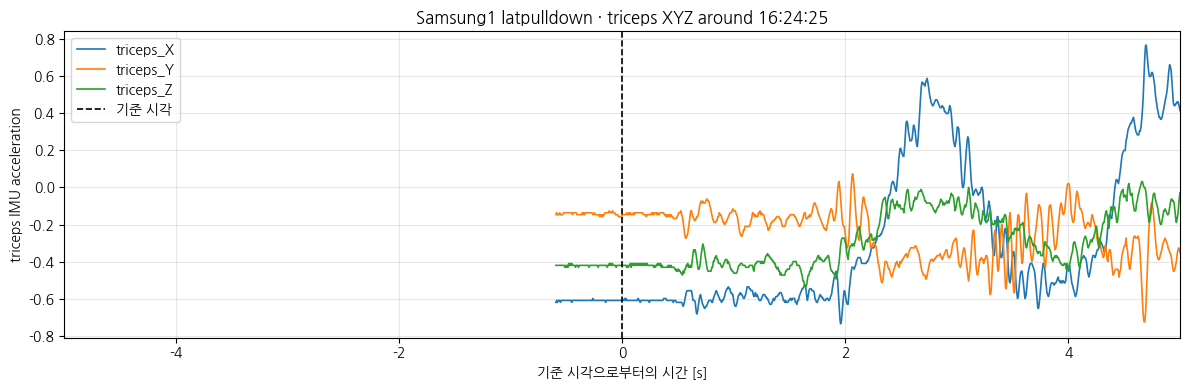

[선택 구간 정보]
filename: sub2_latpulldown_plot_and_store_rep_2.143.csv
center_dt: 2025-06-16 16:24:25
start_dt : 2025-06-16 16:24:20
end_dt   : 2025-06-16 16:24:30
rows     : 10775
time range: 2025-06-16 16:24:24.405754 ~ 2025-06-16 16:24:29.999946


In [11]:
# Samsung1 랫풀다운 16:24:25 기준
lat_wdf = plot_triceps_xyz_around_time(
    s1,
    filename='sub2_latpulldown_plot_and_store_rep_2.143.csv',
    center_time='16:24:25',
    before=5,
    after=5,
    title='Samsung1 latpulldown · triceps XYZ around 16:24:25'
)

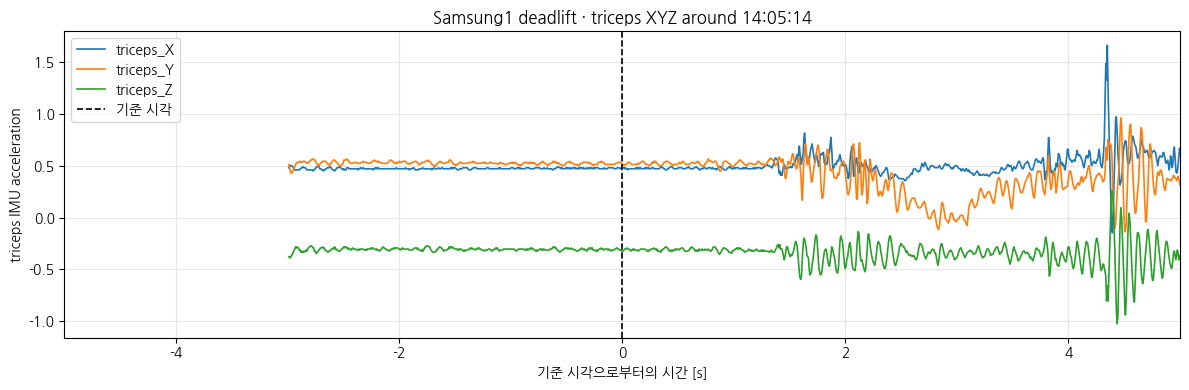

[선택 구간 정보]
filename: sub8_deadllift_plot_and_store_rep_1.40.csv
center_dt: 2025-06-11 14:05:14
start_dt : 2025-06-11 14:05:09
end_dt   : 2025-06-11 14:05:19
rows     : 15386
time range: 2025-06-11 14:05:11.011253 ~ 2025-06-11 14:05:18.999618


In [12]:
# Samsung1 데드리프트 12:21:11 기준
dead_wdf = plot_triceps_xyz_around_time(
    s1,
    filename='sub8_deadllift_plot_and_store_rep_1.40.csv',
    center_time='14:05:14',
    before=5,
    after=5,
    title='Samsung1 deadlift · triceps XYZ around 14:05:14'
)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_samsung2_triceps_xyz_around_time(
    df,
    csv_filename,
    center_time,
    window_sec=1.0,
    session_col='csv_filename_l',
    abs_time_col='TimeStamp',
    channels=('triceps_X', 'triceps_Y', 'triceps_Z'),
    title=None
):
    """
    Samsung2 데이터에서 특정 csv_filename_l 세션의 특정 시각을 기준으로
    triceps_X/Y/Z를 총 window_sec초 동안 시각화한다.

    center_time 예시:
        '10:42:41'
        '09:06:47'
        '2025-09-16 10:42:41'
        '2025-09-16 10:42:41.838'

    시간만 넣으면 해당 세션의 날짜를 자동으로 붙인다.
    """

    # 1. 해당 세션 추출
    sdf = df[df[session_col] == csv_filename].copy()

    if len(sdf) == 0:
        raise ValueError(f"해당 csv_filename_l을 찾을 수 없습니다:\n{csv_filename}")

    # 2. TimeStamp datetime 변환
    sdf[abs_time_col] = pd.to_datetime(sdf[abs_time_col])
    sdf = sdf.sort_values(abs_time_col)

    # 3. center_time 처리
    center_time = str(center_time).strip()

    # '10:42:41'처럼 시간만 넣은 경우, 세션 날짜 자동 사용
    if len(center_time) <= 12:
        session_date = sdf[abs_time_col].iloc[0].date()
        center_dt = pd.to_datetime(f"{session_date} {center_time}")
    else:
        center_dt = pd.to_datetime(center_time)

    # 4. 총 window_sec초 구간 설정
    half = window_sec / 2
    start_dt = center_dt - pd.Timedelta(seconds=half)
    end_dt   = center_dt + pd.Timedelta(seconds=half)

    wdf = sdf[
        (sdf[abs_time_col] >= start_dt) &
        (sdf[abs_time_col] <= end_dt)
    ].copy()

    if len(wdf) == 0:
        raise ValueError(
            f"선택 구간에 데이터가 없습니다.\n"
            f"center={center_dt}\n"
            f"range={start_dt} ~ {end_dt}\n"
            f"session range={sdf[abs_time_col].min()} ~ {sdf[abs_time_col].max()}"
        )

    # 5. 기준 시각을 0초로 하는 상대시간
    wdf['time_from_center'] = (
        wdf[abs_time_col] - center_dt
    ).dt.total_seconds()

    # 6. 시각화
    plt.figure(figsize=(12, 4))

    for ch in channels:
        if ch not in wdf.columns:
            raise ValueError(f"컬럼이 없습니다: {ch}")

        plt.plot(
            wdf['time_from_center'],
            wdf[ch],
            lw=1.2,
            label=ch
        )

    plt.axvline(0, color='black', linestyle='--', lw=1.2, label='기준 시각')
    plt.xlim(-half, half)

    if title is None:
        title = (
            f"Samsung2 · {csv_filename}\n"
            f"center={center_dt} | total window={window_sec}s"
        )

    plt.title(title)
    plt.xlabel("기준 시각으로부터의 시간 [s]")
    plt.ylabel("triceps IMU acceleration")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("[선택 구간 정보]")
    print("csv_filename_l:", csv_filename)
    print("center_dt:", center_dt)
    print("start_dt :", start_dt)
    print("end_dt   :", end_dt)
    print("rows     :", len(wdf))
    print("session time range:", sdf[abs_time_col].min(), "~", sdf[abs_time_col].max())
    print("selected time range:", wdf[abs_time_col].min(), "~", wdf[abs_time_col].max())
    print("exercise:", wdf['exercise'].iloc[0])
    print("subject_id:", wdf['subject_id'].iloc[0])

    return wdf

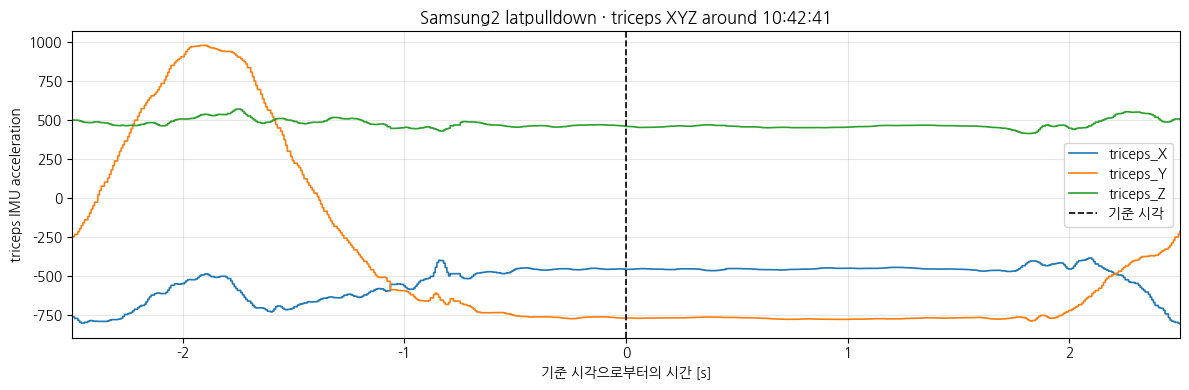

[선택 구간 정보]
csv_filename_l: Data_NINA11_2025.09.16_10.42.27_sub7_latpulldown_1_59_6.csv
center_dt: 2025-09-16 10:42:41
start_dt : 2025-09-16 10:42:38.500000
end_dt   : 2025-09-16 10:42:43.500000
rows     : 10000
session time range: 2025-09-16 10:42:27.309964 ~ 2025-09-16 10:43:06.564464
selected time range: 2025-09-16 10:42:38.500464 ~ 2025-09-16 10:42:43.499964
exercise: latpulldown
subject_id: 7


In [14]:
s2_lat_wdf = plot_samsung2_triceps_xyz_around_time(
    s2,
    csv_filename='Data_NINA11_2025.09.16_10.42.27_sub7_latpulldown_1_59_6.csv',
    center_time='10:42:41',
    window_sec=5.0,
    title='Samsung2 latpulldown · triceps XYZ around 10:42:41'
)

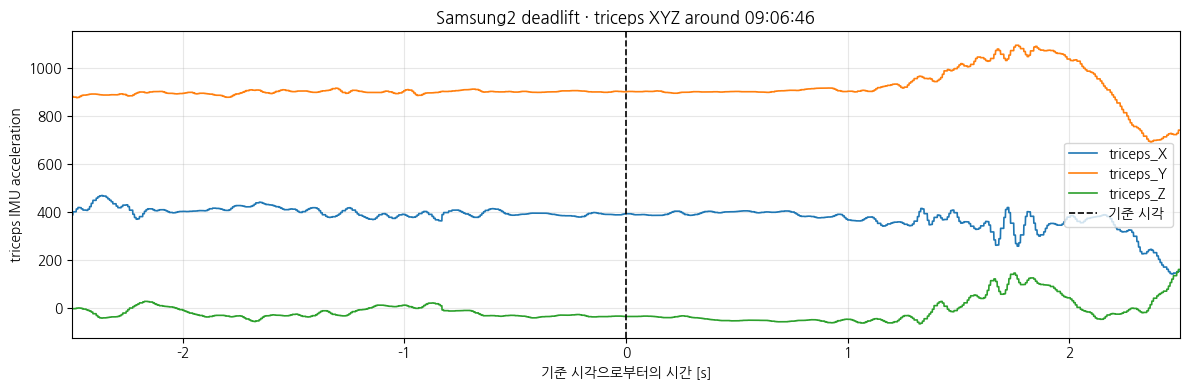

[선택 구간 정보]
csv_filename_l: Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_1_40_6.csv
center_dt: 2025-09-12 09:06:46
start_dt : 2025-09-12 09:06:43.500000
end_dt   : 2025-09-12 09:06:48.500000
rows     : 10000
session time range: 2025-09-12 09:06:40.032669 ~ 2025-09-12 09:07:20.637169
selected time range: 2025-09-12 09:06:43.500169 ~ 2025-09-12 09:06:48.499669
exercise: deadlift
subject_id: 7


In [15]:
s2_dead_wdf = plot_samsung2_triceps_xyz_around_time(
    s2,
    csv_filename='Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_1_40_6.csv',
    center_time='09:06:46',
    window_sec=5.0,
    title='Samsung2 deadlift · triceps XYZ around 09:06:46'
)